# Chain-of-Prompts (CoP): Reproducing Figure 2

We reconstruct the paper's **Figure 2** on a real histopathology image
(`CoNSeP / test_2`, 1000x1000, 245 cells in 3 cell types):

- **O(T), Chain-of-Prompts (ours):** one click *per cell type* (T=3), recursively
  propagated by **HSG + FPR**. Reproduced **live** with `core/cop.py`.
- **O(N), SAM3 per-instance:** one click *per cell* (N=245), shown for reference.

With **3 clicks instead of 245 (81.7x fewer)**, CoP reaches **92.7% of the
per-instance upper bound**, fully training-free.

## What we reproduce

This is the original **Figure 2**. Section 3 rebuilds the *Group Prompting O(T)* row
live; section 4 places it next to *Manual Prompting O(N)* and the **AJI vs. prompts** curve.

![Paper Figure 2](assets/figure2.png)

## 1. Setup

In [1]:
import os, json, math
import cv2
import numpy as np
import matplotlib.pyplot as plt

from core.sam import ImageSAM
from core.cop import ChainOfPrompts

plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12,
                     "axes.titleweight": "bold", "font.size": 10})

EXAMPLES   = "./examples"
FIG2       = os.path.join(EXAMPLES, "figure2")
IMAGE_PATH = os.path.join(EXAMPLES, "CoNSeP_test_2.png")

# SAM3 checkpoint directory (edit to your local / Hugging Face path)
MODEL_DIR = "I:/cache/sam3" if os.name == "nt" else "/mnt/nas5/cache/sam3"

### Visualization helpers

Figure-specific cosmetics (type coloring, star = user click, dot = propagated point),
kept here so `core/cop.py` stays lean.

In [2]:
# One color per cell type, matching the paper figure.
TYPE_RGB = {1:(230,80,80), 2:(80,180,80), 3:(80,80,230),
            4:(230,180,40), 5:(180,80,230), 6:(80,200,200)}
def _bgr(c): return (int(c[2]), int(c[1]), int(c[0]))

def _star(img, cx, cy, r, t, color):
    pts = [[int(cx + (r if i%2==0 else r*0.45)*math.cos(math.pi/2 + i*math.pi/5)),
            int(cy - (r if i%2==0 else r*0.45)*math.sin(math.pi/2 + i*math.pi/5))] for i in range(10)]
    pts = np.array(pts, np.int32)
    cv2.fillPoly(img, [pts], (255,255,255)); cv2.polylines(img, [pts], True, color, t, cv2.LINE_AA)

def _dot(img, cx, cy, r, t, color):
    cv2.circle(img, (cx,cy), r, tuple(min(255,int(v*0.5+128)) for v in color), -1, cv2.LINE_AA)
    cv2.circle(img, (cx,cy), r, color, t, cv2.LINE_AA)

def overlay_typed(cv_bgr, label_map, inst_to_type, clicks, props, alpha=0.4):
    # clicks / props : lists of (x, y, type_id)
    canvas = cv_bgr.copy().astype(np.float32)
    fill = np.zeros_like(canvas); m_any = np.zeros(label_map.shape, bool)
    for iid, tid in inst_to_type.items():
        m = label_map == iid
        if m.any(): fill[m] = _bgr(TYPE_RGB.get(tid,(128,128,128))); m_any |= m
    canvas[m_any] = (1-alpha)*canvas[m_any] + alpha*fill[m_any]
    canvas = canvas.astype(np.uint8)
    base = max(cv_bgr.shape[:2]); sr,pr,tk = max(int(base*0.02),7), max(int(base*0.007),3), max(int(base*0.003),1)
    for (x,y,tid) in props:  _dot(canvas, int(x), int(y), pr, tk, _bgr(TYPE_RGB.get(tid,(128,128,128))))
    for (x,y,tid) in clicks: _star(canvas, int(x), int(y), sr, tk, _bgr(TYPE_RGB.get(tid,(128,128,128))))
    return canvas

def show(ax, bgr, title, frame=None):
    ax.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); ax.set_xticks([]); ax.set_yticks([])
    if frame:
        for s in ax.spines.values(): s.set_color(frame); s.set_linewidth(3)
    else:
        for s in ax.spines.values(): s.set_visible(False)
    ax.set_title(title)

## 2. Load the sample and the type-clicks

The three clicks (one per cell type) are read from `figure2_data.json`, so the
reproduction is data-driven and deterministic.

CoNSeP/test_2   1000x1000   |   N=245 cells, T=3 types
cells per type : {'1': 16, '2': 72, '3': 157}
type-clicks    : [(292, 395), (171, 539), (684, 958)]


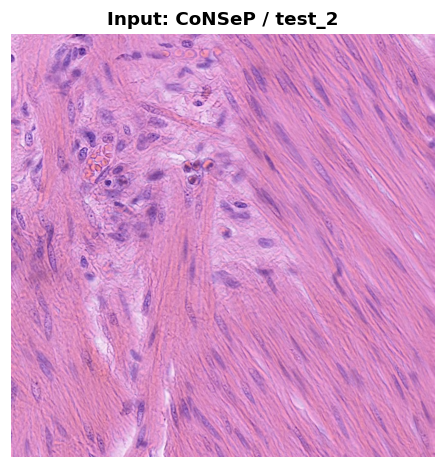

In [3]:
cv_image = cv2.imread(IMAGE_PATH)          # BGR
ih, iw = cv_image.shape[:2]

meta   = json.load(open(os.path.join(FIG2, "figure2_data.json")))
clicks = [tuple(s["user_click"]) for s in meta["cop_steps"]]   # one click per cell type
click_type = [s["type_id"] for s in meta["cop_steps"]]
N, T   = meta["N"], meta["T"]

print(f"{meta['dataset']}/{meta['stem']}   {iw}x{ih}   |   N={N} cells, T={T} types")
print("cells per type :", meta["cell_types"])
print("type-clicks    :", clicks)

plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.title("Input: CoNSeP / test_2"); plt.show()

## 3. Chain-of-Prompts (Ours)

`ChainOfPrompts.segment_steps` replays the method one click at a time. Each panel is
framed in its cell-type color; **star = user click**, **dot = propagated point**.

c:\Users\josan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\josan\AppData\Local\Programs\Python\Python312\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\josan\AppData\Local\Programs\Python\Python312\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
g:\Research Projects\MICCAI2026_Chain-of-Prompts\core\sam\modeling\sam1\tiny_vit_sam.py:662: UserWarning: Overwr

Enabled the use of perflib.
  click 1 (type 1): 152 cells (+151 propagated)
  click 2 (type 2): 167 cells (+15 propagated)
  click 3 (type 3): 185 cells (+18 propagated)


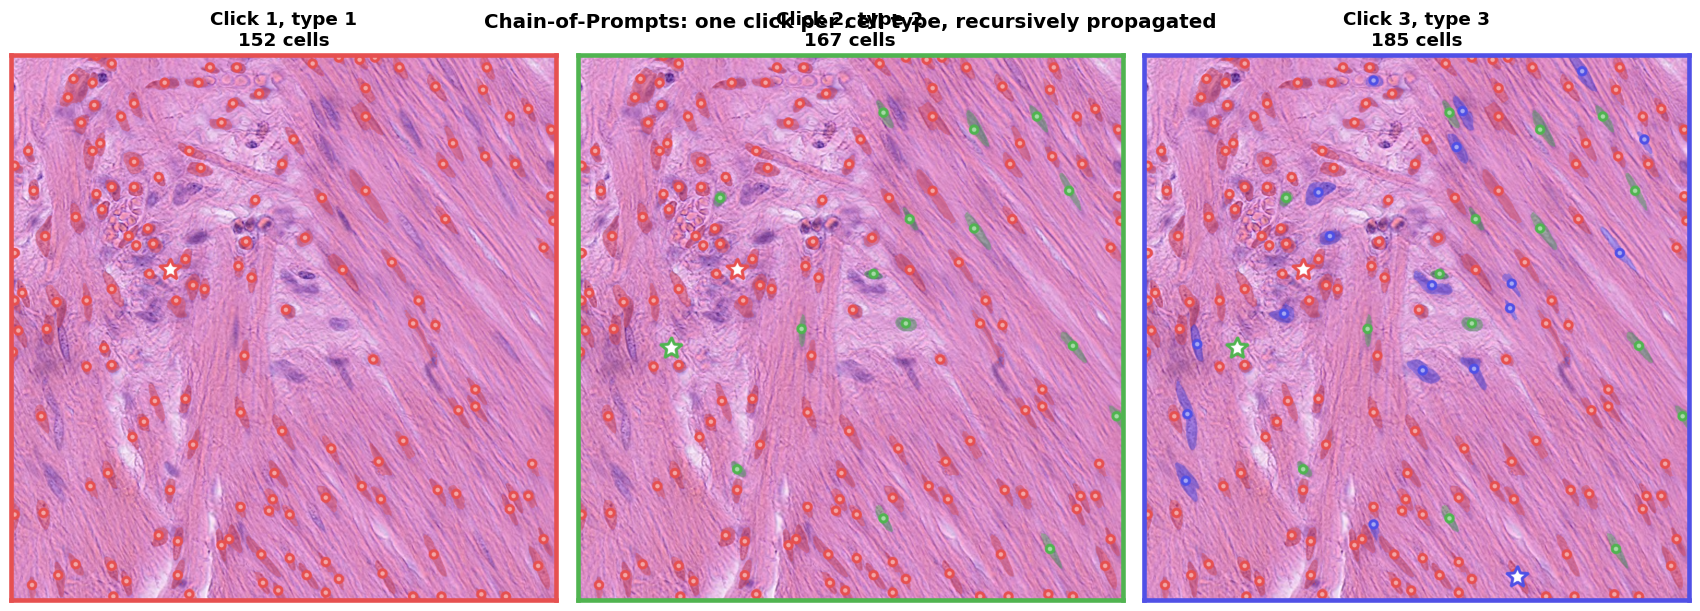

In [ ]:
model = ImageSAM(MODEL_DIR, "sam3")
cop   = ChainOfPrompts(model)

clicks_acc, props_acc, panels = [], [], []
for step in cop.segment_steps(cv_image, clicks):
    ci  = step["click_index"]; tid = click_type[ci]
    clicks_acc.append((*step["user_click"], tid))
    props_acc += [(int(x), int(y), tid) for (x, y) in step["propagated_points"]]
    inst_to_type = {iid: click_type[c] for iid, c in step["inst_to_click"].items()}
    panels.append((step, overlay_typed(cv_image, step["label_map"], inst_to_type, clicks_acc, props_acc)))
    print(f"  click {ci+1} (type {tid}): {step['num_instances']:>3} cells "
          f"(+{len(step['propagated_points'])} propagated)")

fig, axes = plt.subplots(1, len(panels), figsize=(5.2*len(panels), 5.6))
# fig.suptitle("Chain-of-Prompts: one click per cell type, recursively propagated", fontsize=13, fontweight="bold")
for ax, (step, panel) in zip(np.atleast_1d(axes), panels):
    ci = step["click_index"]; tid = click_type[ci]
    show(ax, panel, f"Click {ci+1}, type {tid}\n{step['num_instances']} cells",
         frame="#%02x%02x%02x" % TYPE_RGB[tid])
plt.tight_layout(); plt.show()

## 4. Results: one click per type vs. one click per cell

Left: **ours O(T)**, reproduced live with 3 clicks. Right: **SAM3 O(N)** with 245 clicks.
Below: **AJI vs. number of prompts**, where CoP (green, type-colored stars) reaches 92.7% of the
per-instance upper bound at just 3 clicks.

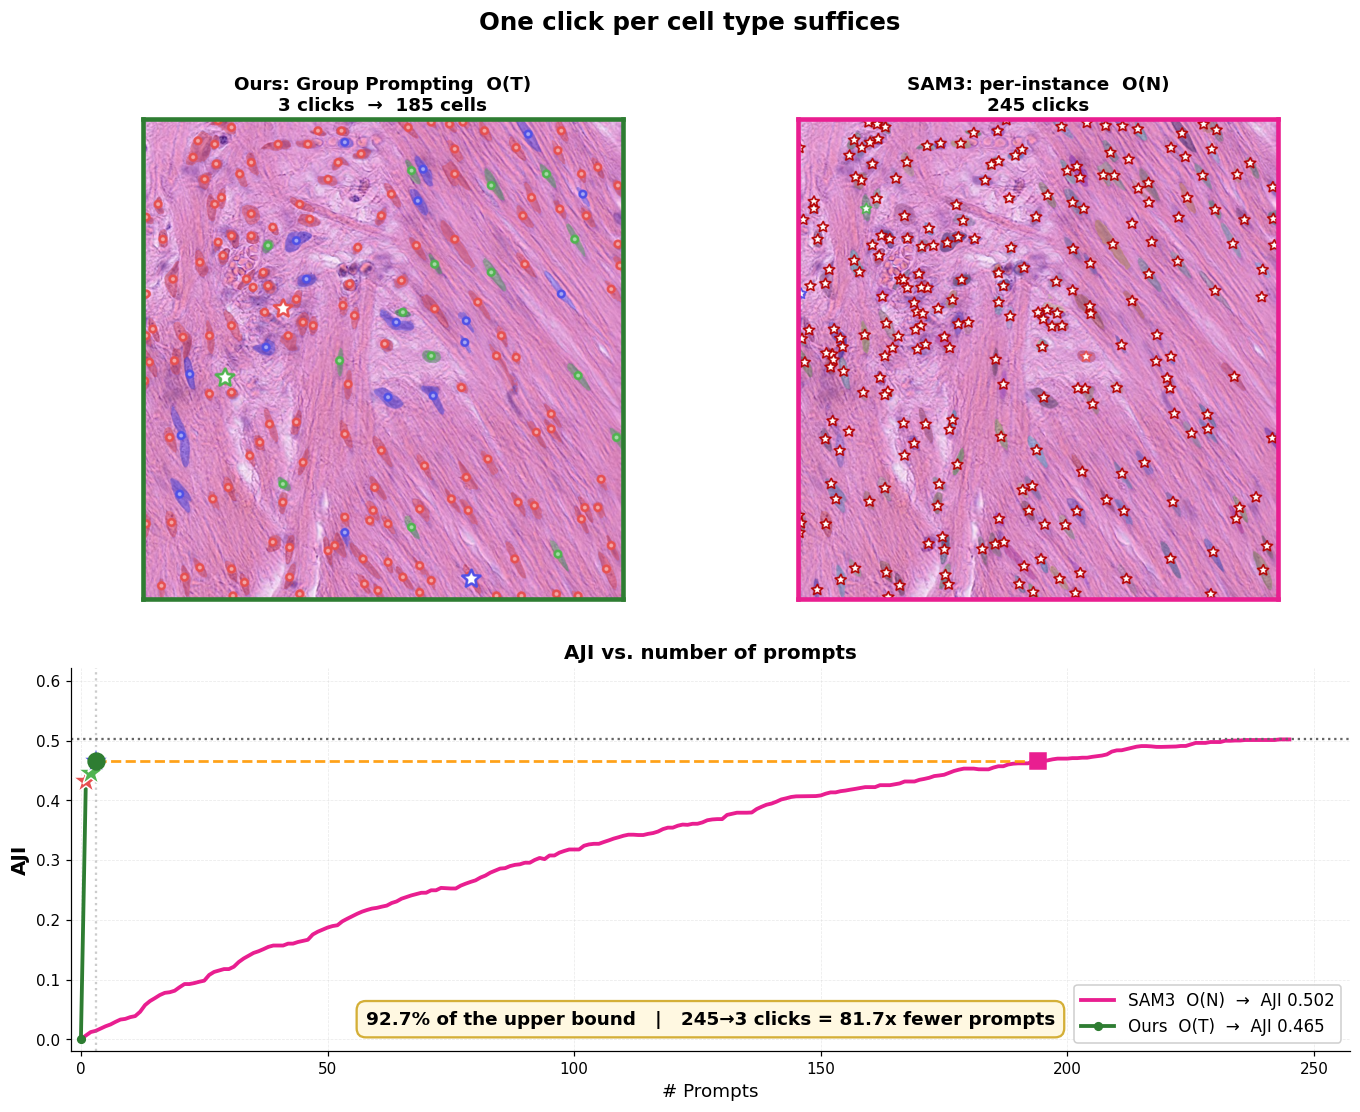

In [8]:
curve   = json.load(open(os.path.join(FIG2, "aji_curve.json")))
sam_ovl = cv2.imread(os.path.join(FIG2, "ON_final_overlay.png"))   # SAM3 @245 (overlay, consistent)
our_ovl = panels[-1][1]
our_cells = panels[-1][0]["num_instances"]

cop_aji, ub = curve["cop_final_aji"], curve["ub_aji"]
sx, sy = curve["sam3_curve"]["x"], curve["sam3_curve"]["y"]
cx, cy = curve["cop_curve"]["x"],  curve["cop_curve"]["y"]
sam_equiv = next((k for k, y in zip(sx, sy) if k > 0 and y >= cop_aji), N)   # SAM3 clicks for same AJI

fig = plt.figure(figsize=(15, 11))
fig.suptitle("One click per cell type suffices", fontsize=16, fontweight="bold", y=0.97)
gs = fig.add_gridspec(2, 2, height_ratios=[1.25, 1], hspace=0.16, wspace=0.05)

show(fig.add_subplot(gs[0,0]), our_ovl,
     f"Ours: Group Prompting  O(T)\n{T} clicks  →  {our_cells} cells", frame="#2E7D32")
show(fig.add_subplot(gs[0,1]), sam_ovl,
     f"SAM3: per-instance  O(N)\n{N} clicks", frame="#E91E90")

ax = fig.add_subplot(gs[1, :])
ax.set_facecolor("#FFFFFF")
ax.grid(axis="both", linestyle="--", linewidth=0.5, alpha=0.4, color="#CCCCCC"); ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.plot(sx, sy, color="#E91E90", linewidth=2.5, label=f"SAM3  O(N)  →  AJI {curve['sam3_final_aji']:.3f}")
ax.axhline(ub, color="#666", linestyle=":", linewidth=1.5) # label=f"Upper bound  →  AJI {ub:.3f}")
ax.plot(cx, cy, color="#2E7D32", linewidth=2.5, marker="o", markersize=5,
        label=f"Ours  O(T)  →  AJI {cop_aji:.3f}")
for i in range(len(curve["cop_curve"]["type_ids"])):
    c = [v/255 for v in curve["cop_curve"]["type_colors_rgb"][i]]
    ax.plot(cx[i+1], cy[i+1], marker="*", markersize=18, color=c,
            markeredgecolor="white", markeredgewidth=1.0, zorder=6)
ax.plot([T, sam_equiv], [cop_aji, cop_aji], color="#FF9800", linestyle="--", linewidth=1.8, alpha=0.9)
ax.plot(T, cop_aji, "o", color="#2E7D32", markersize=11, zorder=7)
ax.plot(sam_equiv, cop_aji, "s", color="#E91E90", markersize=11, zorder=7)
ax.axvline(T, color="gray", linestyle=":", alpha=0.4)
ax.text(0.5, 0.06,
        f"{curve['gap_pct']:.1f}% of the upper bound   |   {N}\u2192{T} clicks = {N/T:.1f}x fewer prompts",
        transform=ax.transAxes, ha="center", va="bottom", fontsize=12, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#FFF8E1", edgecolor="#D4AF37", linewidth=1.5))
ax.set_xlabel("# Prompts", fontsize=12); ax.set_ylabel("AJI", fontsize=13, fontweight="bold")
ax.set_xlim(-2, N*1.05); ax.set_ylim(-0.02, min(ub+0.12, 1.02))
ax.set_title("AJI vs. number of prompts", fontsize=13)
ax.legend(loc="lower right", fontsize=11, framealpha=0.95, edgecolor="#CCCCCC")
plt.show()

## 5. Summary

In [6]:
print("=" * 58)
print(f"  Chain-of-Prompts: {meta['dataset']}/{meta['stem']}")
print("=" * 58)
print(f"  Cells (N)             : {N}")
print(f"  Cell types (T)        : {T}")
print(f"  Clicks used (ours)    : {T}    →  {N/T:.1f}x fewer than O(N)")
print(f"  Cells found (live)    : {our_cells}")
print(f"  AJI  ours / upper b.  : {cop_aji:.3f} / {ub:.3f}   ({curve['gap_pct']:.1f}% of upper bound)")
print("=" * 58)

  Chain-of-Prompts: CoNSeP/test_2
  Cells (N)             : 245
  Cell types (T)        : 3
  Clicks used (ours)    : 3    →  81.7x fewer than O(N)
  Cells found (live)    : 185
  AJI  ours / upper b.  : 0.465 / 0.502   (92.7% of upper bound)
